In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:

# 1. 원본 텍스트 데이터 (입력하신 데이터를 기반으로 함)
raw_data = """
house_001: ch01, ch02, ch03, ch04, ch05, ch06, ch07, ch09, ch10, ch17, ch20, ch21, ch23
house_002: ch01, ch02, ch03, ch04, ch05, ch06, ch07, ch09, ch10, ch13, ch14, ch16, ch18, ch21, ch22, ch23
house_003: ch01, ch02, ch03, ch04, ch05, ch06, ch07, ch09, ch10, ch11, ch14, ch20, ch23
house_004: ch01, ch02, ch03, ch04, ch06, ch07, ch09, ch10, ch11, ch12, ch13, ch21
house_005: ch01, ch02, ch03, ch04, ch05, ch07, ch09, ch10, ch12, ch16, ch17, ch18, ch19, ch20, ch21, ch22
house_006: ch01, ch03, ch04, ch06, ch07, ch09, ch10, ch13, ch14, ch17, ch19, ch20, ch21, ch23
house_007: ch01, ch07, ch09, ch10, ch13, ch17, ch19, ch20, ch21
house_008: ch01, ch03, ch04, ch05, ch06, ch07, ch09, ch10, ch14, ch15, ch16, ch17, ch20, ch21, ch23
house_009: ch01, ch02, ch03, ch04, ch05, ch06, ch07, ch09, ch10, ch15, ch18, ch21, ch23
house_010: ch01, ch02, ch03, ch04, ch05, ch06, ch07, ch09, ch11, ch18, ch19, ch21, ch23
house_011: ch01, ch02, ch03, ch04, ch06, ch07, ch08, ch09, ch10, ch13, ch14, ch15, ch16, ch17, ch20, ch21, ch22, ch23
house_012: ch01, ch02, ch03, ch04, ch05, ch07, ch09, ch10, ch13, ch14, ch18, ch20, ch21
house_013: ch01, ch02, ch03, ch06, ch07, ch09, ch10, ch14, ch18, ch19, ch20, ch22, ch23
house_014: ch01, ch02, ch03, ch04, ch05, ch06, ch07, ch10, ch11, ch16, ch18, ch21, ch23
house_015: ch01, ch03, ch04, ch05, ch06, ch07, ch08, ch09, ch10, ch11, ch12, ch13, ch14, ch17, ch20, ch21, ch23
house_016: ch01, ch03, ch04, ch07, ch09, ch10, ch12, ch14, ch17, ch19, ch20, ch23
house_017: ch01, ch02, ch03, ch04, ch05, ch06, ch09, ch10, ch11, ch13, ch14, ch15, ch16, ch17, ch18, ch19, ch21, ch22
house_018: ch01, ch02, ch03, ch05, ch06, ch07, ch08, ch09, ch10, ch13, ch18, ch21, ch23
house_019: ch01, ch02, ch03, ch04, ch05, ch06, ch07, ch09, ch11, ch13, ch19, ch20, ch21
house_020: ch01, ch03, ch04, ch05, ch06, ch07, ch09, ch10, ch16
house_021: ch01, ch08, ch09, ch10, ch11, ch14, ch15, ch16, ch18, ch21
house_024: ch01, ch05, ch12, ch16, ch17, ch19, ch20, ch21, ch22
house_025: ch01, ch05, ch09, ch10, ch14, ch15, ch16, ch17, ch20, ch21
house_028: ch01, ch05, ch09, ch11, ch14, ch16, ch17, ch18, ch19, ch21
house_031: ch01, ch02, ch03, ch04, ch05, ch06, ch07, ch08, ch09, ch12, ch13, ch16, ch17, ch18, ch19, ch22
house_032: ch01, ch02, ch03, ch04, ch06, ch07, ch09, ch13, ch17, ch21, ch22
house_033: ch01, ch02, ch03, ch04, ch05, ch06, ch07, ch09, ch10, ch11, ch13, ch18, ch19, ch23
house_034: ch01, ch02, ch04, ch06, ch09, ch10, ch11, ch13, ch14, ch16, ch19, ch23
house_035: ch01, ch02, ch03, ch04, ch05, ch06, ch07, ch08, ch09, ch10, ch11, ch13, ch14, ch17, ch18, ch20, ch23
house_036: ch01, ch02, ch03, ch06, ch07, ch13, ch14, ch17, ch18, ch21, ch22, ch23
house_037: ch01, ch03, ch05, ch06, ch07, ch09, ch11, ch13, ch17, ch23
house_038: ch01, ch02, ch03, ch04, ch05, ch06, ch07, ch10, ch12, ch13, ch14, ch17, ch19, ch23
house_039: ch01, ch03, ch04, ch05, ch07, ch08, ch13, ch16, ch17, ch19, ch21
house_040: ch01, ch02, ch03, ch04, ch05, ch06, ch07, ch09, ch10, ch13, ch17, ch21
house_041: ch01, ch03, ch04, ch05, ch07, ch08, ch13, ch16, ch17, ch19, ch21, ch23
house_042: ch01, ch02, ch03, ch05, ch06, ch07, ch09, ch10, ch14, ch17, ch20, ch21, ch22, ch23
house_043: ch01, ch03, ch04, ch05, ch06, ch07, ch09, ch10, ch13, ch15, ch17, ch19, ch21, ch22, ch23
house_044: ch01, ch02, ch03, ch04, ch05, ch06, ch07, ch08, ch09, ch10, ch13, ch14, ch18, ch20, ch21, ch22
house_045: ch01, ch02, ch03, ch04, ch06, ch07, ch10, ch13, ch15, ch18, ch19, ch20, ch21, ch22, ch23
house_046: ch01, ch02, ch03, ch04, ch05, ch06, ch07, ch08, ch09, ch10, ch11, ch13, ch14, ch19, ch21, ch22, ch23
house_047: ch01, ch03, ch04, ch05, ch06, ch08, ch09, ch13, ch17, ch19
house_048: ch01, ch02, ch03, ch04, ch05, ch06, ch07, ch09, ch10, ch11, ch13, ch14, ch15, ch17, ch18
house_049: ch01, ch02, ch03, ch04, ch05, ch06, ch07, ch08, ch09, ch11, ch12, ch13, ch14, ch16, ch17, ch18, ch19, ch21, ch22
house_050: ch01, ch02, ch03, ch05, ch06, ch07, ch08, ch09, ch10, ch11, ch14, ch16, ch21, ch22, ch23
house_051: ch01, ch03, ch04, ch05, ch06, ch07, ch08, ch13, ch14, ch16, ch20, ch21, ch23
house_052: ch01, ch02, ch04, ch05, ch06, ch07, ch09, ch10, ch17, ch18, ch21, ch23
house_053: ch01, ch03, ch04, ch05, ch06, ch07, ch09, ch10, ch14, ch18, ch19, ch20, ch21, ch23
house_054: ch01, ch02, ch03, ch04, ch05, ch06, ch07, ch09, ch11, ch13, ch14, ch15, ch17, ch18, ch19, ch20, ch21, ch22, ch23
house_055: ch01, ch02, ch04, ch06, ch07, ch08, ch10, ch11, ch12, ch13, ch14, ch16, ch17, ch19, ch20, ch22
house_056: ch01, ch02, ch03, ch04, ch05, ch06, ch07, ch08, ch09, ch10, ch11, ch12, ch19
house_058: ch01, ch02, ch03, ch04, ch05, ch06, ch07, ch08, ch10, ch16, ch18, ch19, ch21, ch22, ch23
house_059: ch01, ch02, ch03, ch04, ch05, ch07, ch09, ch13, ch17, ch18, ch21, ch22, ch23
house_060: ch01, ch02, ch04, ch05, ch07, ch08, ch10, ch11, ch18, ch19, ch21, ch22, ch23
house_061: ch01, ch02, ch03, ch04, ch06, ch07, ch10, ch11, ch12, ch16, ch19, ch20, ch21, ch22, ch23
house_062: ch01, ch02, ch03, ch04, ch06, ch07, ch10, ch11, ch15, ch18, ch19
house_063: ch01, ch02, ch03, ch05, ch06, ch07, ch08, ch09, ch10, ch13, ch17, ch18, ch19, ch21, ch22, ch23
house_064: ch01, ch03, ch04, ch05, ch07, ch10, ch15, ch18, ch19, ch20, ch23
house_065: ch01, ch02, ch03, ch04, ch06, ch07, ch08, ch10, ch11, ch12, ch13, ch17, ch18, ch19, ch20, ch21, ch22
house_066: ch01, ch02, ch03, ch05, ch06, ch07, ch08, ch09, ch13, ch19
house_067: ch01, ch02, ch03, ch04, ch05, ch06, ch07, ch08, ch09, ch10, ch11, ch13, ch14, ch15, ch16, ch17, ch18, ch19, ch20, ch21, ch22, ch23
house_068: ch01, ch02, ch03, ch04, ch07, ch13, ch16, ch17, ch18, ch19, ch20, ch22, ch23
house_071: ch01, ch08, ch11, ch15, ch16, ch18, ch19, ch20, ch21, ch22
house_075: ch01, ch11, ch13, ch14, ch15, ch16, ch17, ch18, ch19, ch20, ch21
house_087: ch01, ch04, ch11, ch14, ch15, ch16, ch17, ch18, ch19, ch21, ch22
house_088: ch01, ch02, ch04, ch05, ch07, ch09, ch11, ch19, ch20, ch21, ch22
house_089: ch01, ch02, ch04, ch05, ch07, ch09, ch13, ch14, ch17, ch21, ch22
house_092: ch01, ch04, ch05, ch07, ch11, ch12, ch13, ch18, ch21, ch22
house_093: ch01, ch02, ch04, ch05, ch09, ch14, ch18, ch19, ch21, ch22
house_094: ch01, ch04, ch05, ch07, ch09, ch13, ch14, ch17, ch18, ch19, ch20, ch22
house_096: ch01, ch04, ch05, ch07, ch08, ch11, ch13, ch16, ch17, ch18, ch20, ch22
house_097: ch01, ch04, ch05, ch07, ch08, ch09, ch11, ch13, ch16, ch17, ch20, ch21
house_099: ch01, ch02, ch04, ch05, ch07, ch08, ch13, ch16, ch17, ch18, ch20, ch21, ch22
house_104: ch01, ch04, ch05, ch07, ch09, ch11, ch13, ch16, ch18, ch21, ch22
house_106: ch01, ch04, ch05, ch06, ch07, ch09, ch10, ch11, ch13, ch16, ch19, ch20, ch21
house_108: ch01, ch03, ch04, ch05, ch07, ch11, ch12, ch14, ch18, ch19
house_109: ch01, ch04, ch05, ch09, ch16, ch17, ch20, ch21, ch22
house_110: ch01, ch04, ch05, ch09, ch11, ch16, ch17, ch20, ch21
house_111: ch01, ch04, ch09, ch10, ch12, ch16, ch18, ch21, ch22
house_112: ch01, ch04, ch05, ch06, ch09, ch17, ch18, ch20, ch21 
"""

# 2. 데이터 파싱 및 행렬 변환
data_list = []
for line in raw_data.strip().split('\n'):
    house_id, channels = line.split(':')
    ch_list = [c.strip() for c in channels.split(',')]
    for ch in ch_list:
        if ch.startswith('ch'):
            data_list.append({'house_id': house_id.strip(), 'channel': ch})

df = pd.DataFrame(data_list)
pivot_df = df.pivot_table(index='house_id', columns='channel', aggfunc='size', fill_value=0).clip(upper=1)

# CSV 저장 (모델 학습용 데이터셋 리스트로 활용 가능)
pivot_df.to_csv('house_channel_matrix.csv')



In [6]:
appliance_types = {
    'Type 1': ['ch02', 'ch03', 'ch04'],
    'Type 2': ['ch05', 'ch06', 'ch07', 'ch08', 'ch09', 'ch10', 'ch11', 'ch12'],
    'Type 3': ['ch13', 'ch14', 'ch15', 'ch16', 'ch17', 'ch18', 'ch19', 'ch20'],
    'Type 4': ['ch21', 'ch22', 'ch23'],
}

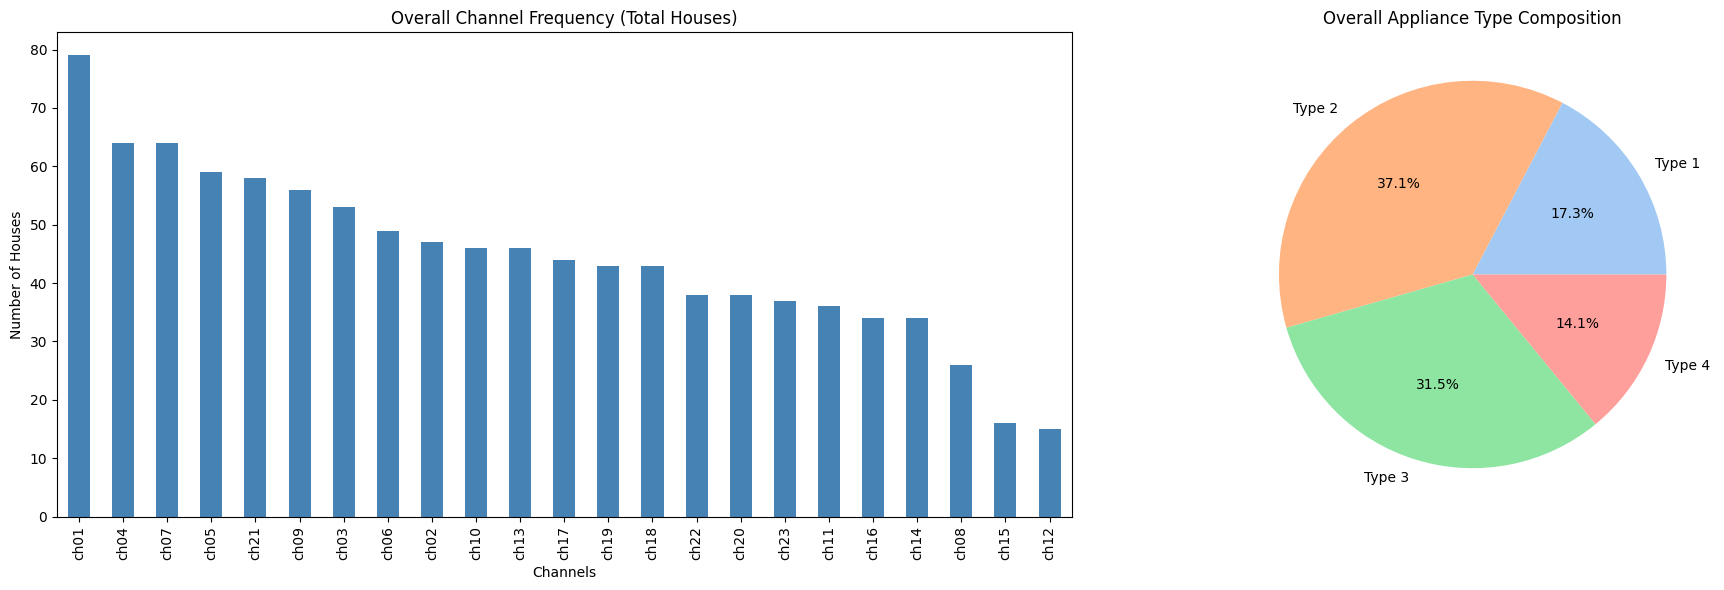

In [7]:
# 3. 전체 데이터 EDA (Exploratory Data Analysis)
def run_overall_eda(df, types):
    plt.figure(figsize=(20, 6))
    
    # [시각화 1] 채널별 보유 가구 수 (등장 빈도)
    plt.subplot(1, 2, 1)
    df.sum().sort_values(ascending=False).plot(kind='bar', color='steelblue')
    plt.title('Overall Channel Frequency (Total Houses)')
    plt.xlabel('Channels')
    plt.ylabel('Number of Houses')

    # [시각화 2] 가전 타입별 전체 비중
    plt.subplot(1, 2, 2)
    type_counts = {t: df[[c for c in chs if c in df.columns]].sum().sum() for t, chs in types.items()}
    plt.pie(type_counts.values(), labels=type_counts.keys(), autopct='%1.1f%%', colors=sns.color_palette('pastel'))
    plt.title('Overall Appliance Type Composition')
    
    plt.tight_layout()
    plt.show()

run_overall_eda(pivot_df, appliance_types)

## 균등분포

In [8]:

def select_perfectly_balanced_houses(df, types, target_count=8):
    selected = []
    remaining = list(df.index)
    target_types = ['Type 1', 'Type 2', 'Type 3', 'Type 4']
    ideal_dist = pd.Series(0.25, index=target_types)
    
    print("=== Enhanced Balanced Selection Starting ===")
    
    for i in range(target_count):
        if not selected:
            # 1. 시작은 여전히 house_067 (데이터 베이스라인)
            best_house = 'house_067'
        else:
            # 2. Step 2까지는 커버리지 100% 달성 우선 (보통 Step 2에서 끝남)
            current_coverage = df.loc[selected].max(axis=0)
            if (current_coverage == 0).any():
                gain = df.loc[remaining].apply(lambda row: ((row == 1) & (current_coverage == 0)).sum(), axis=1)
                best_house = gain.idxmax()
            else:
                # 3. [핵심] Step 3부터는 오직 '25% 균등 비중'과의 오차(MSE)만 보고 판단
                best_error = float('inf')
                best_house = None
                
                for candidate in remaining:
                    temp_selected = selected + [candidate]
                    temp_df = df.loc[temp_selected]
                    
                    # 현재 샘플들의 타입별 기기 총 개수
                    counts = {t: temp_df[[c for c in types[t] if c in df.columns]].sum().sum() for t in target_types}
                    total = sum(counts.values())
                    
                    if total == 0: continue
                    temp_dist = pd.Series(counts) / total
                    
                    # 목표(0.25)와의 평균 제곱 오차 계산
                    error = ((ideal_dist - temp_dist) ** 2).mean()
                    
                    # 만약 이미 비중이 높은 Type 2를 더 높이는 가구라면 패널티 부여 가능
                    if error < best_error:
                        best_error = error
                        best_house = candidate
        
        selected.append(best_house)
        remaining.remove(best_house)
        print(f"Step {i+1}: {best_house} 선정 완료")
        
    return selected

# 실행 후 그래프 다시 그려보기
final_8_houses = select_perfectly_balanced_houses(pivot_df, appliance_types)
final_df = pivot_df.loc[final_8_houses]

=== Enhanced Balanced Selection Starting ===
Step 1: house_067 선정 완료
Step 2: house_004 선정 완료
Step 3: house_059 선정 완료
Step 4: house_036 선정 완료
Step 5: house_032 선정 완료
Step 6: house_045 선정 완료
Step 7: house_093 선정 완료
Step 8: house_058 선정 완료


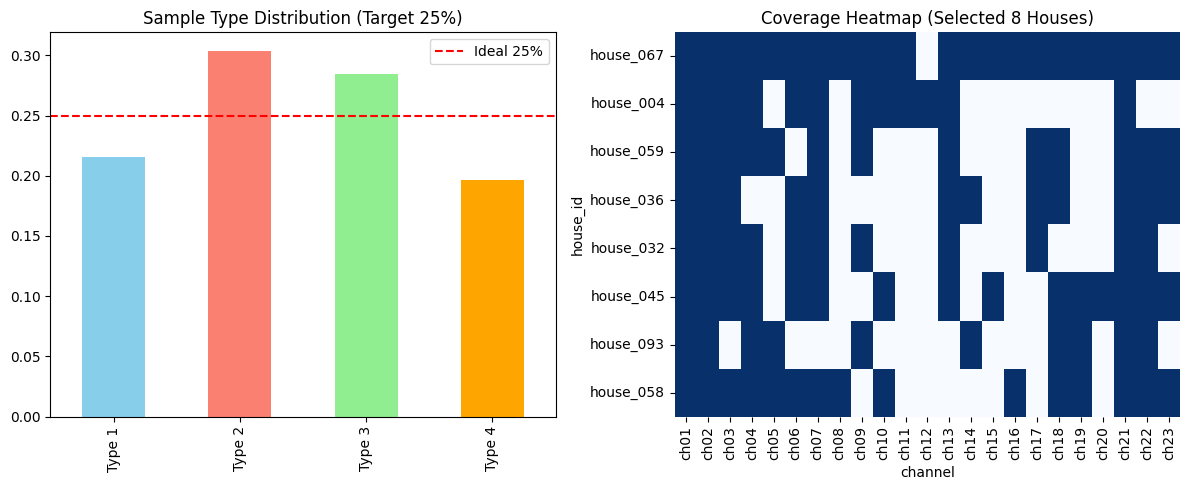


최종 선정 가구: ['house_067', 'house_004', 'house_059', 'house_036', 'house_032', 'house_045', 'house_093', 'house_058']


In [9]:

# 6. 시각화 (합리성 증명)
plt.figure(figsize=(12, 5))

# [시각화 1] 타입별 비중 (목표치 25%와 비교)
plt.subplot(1, 2, 1)
final_counts = {t: final_df[[c for c in appliance_types[t] if c in pivot_df.columns]].sum().sum() for t in appliance_types}
final_dist = pd.Series(final_counts) / sum(final_counts.values())
final_dist.plot(kind='bar', color=['skyblue', 'salmon', 'lightgreen', 'orange', 'plum'])
plt.axhline(y=0.25, color='red', linestyle='--', label='Ideal 25%')
plt.title('Sample Type Distribution (Target 25%)')
plt.legend()

# [시각화 2] 선정된 8개 가구의 채널 보유 히트맵
plt.subplot(1, 2, 2)
sns.heatmap(final_df, cmap='Blues', cbar=False)
plt.title('Coverage Heatmap (Selected 8 Houses)')

plt.tight_layout()
plt.show()

print("\n최종 선정 가구:", final_8_houses)


## 여전히 불균형인 이유

Type 2의 지배력: 전체 가구 데이터를 통틀어 Type 2(주방 가전 등)에 속하는 기기들이 가장 많이 보급되어 있습니다. 어떤 가구를 뽑든 그 가구가 Type 2 기기를 한두 개만 가진 경우는 드물고, 뭉텅이로 가지고 있을 확률이 높습니다.

Type 4의 희소성: Type 4 기기를 가진 가구 자체가 적습니다. 설령 Type 4를 가진 가구를 뽑더라도, 그 가구가 Type 2나 Type 3도 동시에 많이 가지고 있다면 분모(전체 기기 수)가 커지면서 Type 4의 비율은 상대적으로 낮게 유지됩니다.

Trade-off (상충 관계): 23개 채널을 다 포함하려면 특정 가구들을 반드시 뽑아야 하는데, 그 가구들이 Type 2를 많이 들고 있다면 비율을 낮추고 싶어도 낮출 수가 없는 "수학적 막다른 길"에 다다른 것입니다.

## 샘플링 된 10개의 house를 사용한다면


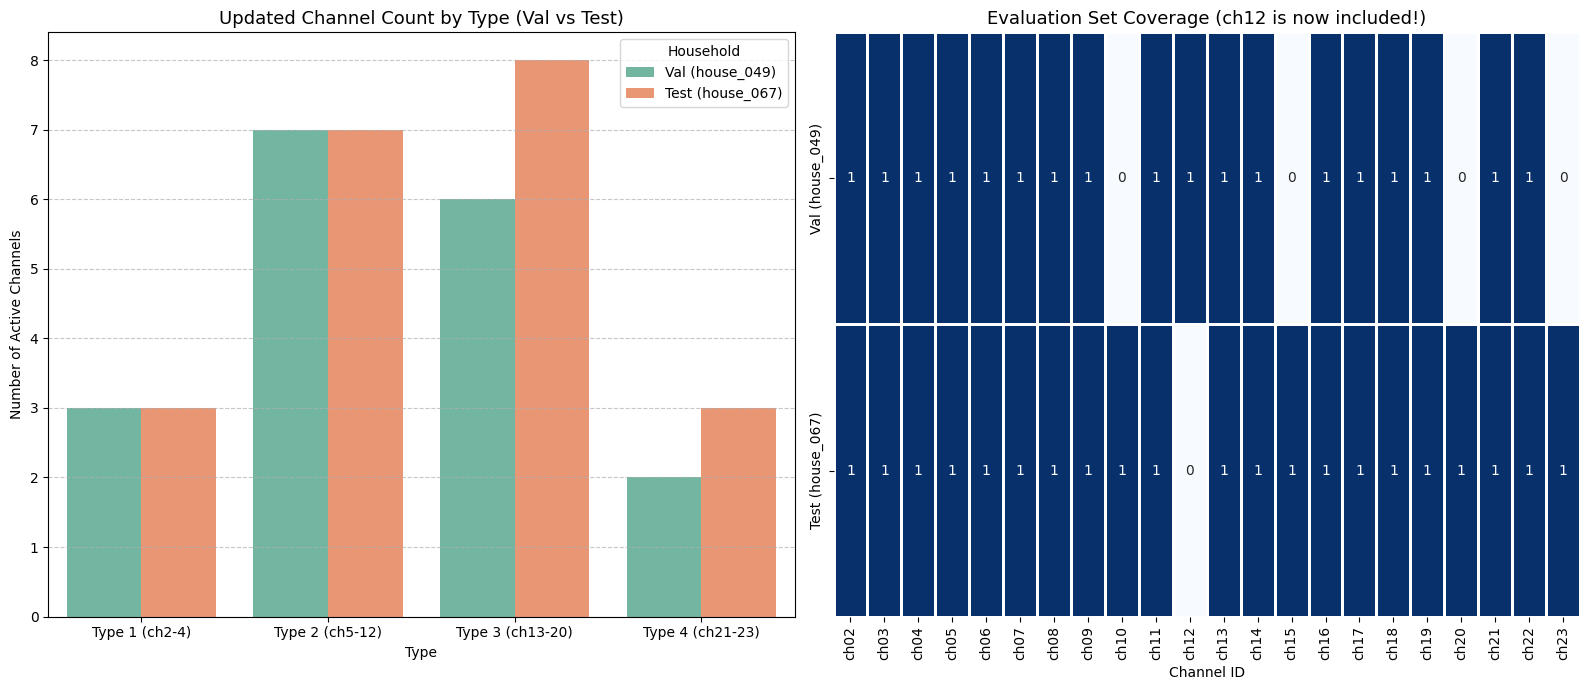

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 수정된 Val(049)과 Test(067) 채널 데이터 정의
eval_house_data = {
    "Val (house_049)": [1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14, 16, 17, 18, 19, 21, 22],
    "Test (house_067)": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
}

# 2. Type 정의
appliance_types = {
    "Type 1 (ch2-4)": ["ch02", "ch03", "ch04"],
    "Type 2 (ch5-12)": ["ch05", "ch06", "ch07", "ch08", "ch09", "ch10", "ch11", "ch12"],
    "Type 3 (ch13-20)": ["ch13", "ch14", "ch15", "ch16", "ch17", "ch18", "ch19", "ch20"],
    "Type 4 (ch21-23)": ["ch21", "ch22", "ch23"]
}

# 3. 히트맵 데이터프레임 생성
ids = list(eval_house_data.keys())
all_channels = [f"ch{i:02d}" for i in range(1, 24)]
matrix = [[1 if int(ch[2:]) in eval_house_data[hid] else 0 for ch in all_channels] for hid in ids]
df_eval = pd.DataFrame(matrix, index=ids, columns=all_channels)

# 4. 시각화 실행
plt.figure(figsize=(16, 7))

# [왼쪽] Val vs Test 타입별 채널 보유 개수 비교
plt.subplot(1, 2, 1)
type_data = []
for hid in ids:
    for t_name, t_chs in appliance_types.items():
        count = df_eval.loc[hid, t_chs].sum()
        type_data.append({'Household': hid, 'Type': t_name, 'Count': count})

df_type_comp = pd.DataFrame(type_data)
sns.barplot(data=df_type_comp, x='Type', y='Count', hue='Household', palette='Set2')
plt.title('Updated Channel Count by Type (Val vs Test)', fontsize=13)
plt.ylabel('Number of Active Channels')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# [오른쪽] Val & Test 채널 커버리지 히트맵
plt.subplot(1, 2, 2)
# ch01(메인)은 당연히 있으니 제외하고 시각화
sns.heatmap(df_eval.drop(columns=['ch01']), cmap='Blues', cbar=False, annot=True, linewidths=1)
plt.title('Evaluation Set Coverage (ch12 is now included!)', fontsize=13)
plt.xlabel('Channel ID')

plt.tight_layout()
plt.show()

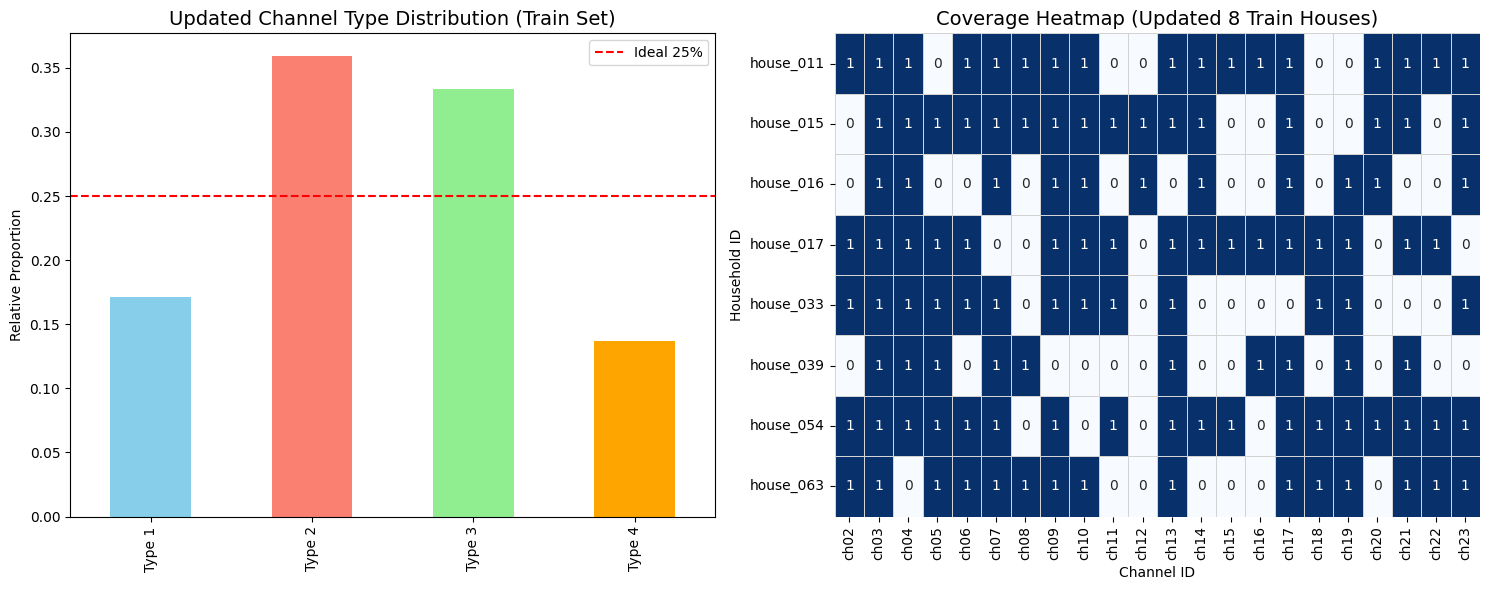

✅ 확인 완료: 모든 채널(ch02~ch23)이 Train 세트에 포함되어 있습니다.


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 수정된 Train 가구별 채널 데이터 정의 (house_049 제외, house_054 추가)
house_channels = {
    "house_011": [1, 2, 3, 4, 6, 7, 8, 9, 10, 13, 14, 15, 16, 17, 20, 21, 22, 23],
    "house_015": [1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 17, 20, 21, 23],
    "house_016": [1, 3, 4, 7, 9, 10, 12, 14, 17, 19, 20, 23],
    "house_017": [1, 2, 3, 4, 5, 6, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19, 21, 22],
    "house_033": [1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 13, 18, 19, 23],
    "house_039": [1, 3, 4, 5, 7, 8, 13, 16, 17, 19, 21],
    "house_054": [1, 2, 3, 4, 5, 6, 7, 9, 11, 13, 14, 15, 17, 18, 19, 20, 21, 22, 23], # 새로 추가
    "house_063": [1, 2, 3, 5, 6, 7, 8, 9, 10, 13, 17, 18, 19, 21, 22, 23]
}

# 2. 분석용 데이터프레임 생성
train_ids = list(house_channels.keys())
# 전체 채널 범위 (ch01~ch23)
all_channels_list = [f"ch{c:02d}" for c in range(1, 24)]
matrix = [[1 if int(ch[2:]) in house_channels[hid] else 0 for ch in all_channels_list] for hid in train_ids]
df_coverage = pd.DataFrame(matrix, index=train_ids, columns=all_channels_list)

# 3. Type 정의 (ch01 제외)
appliance_types = {
    "Type 1": ["ch02", "ch03", "ch04"],
    "Type 2": ["ch05", "ch06", "ch07", "ch08", "ch09", "ch10", "ch11", "ch12"],
    "Type 3": ["ch13", "ch14", "ch15", "ch16", "ch17", "ch18", "ch19", "ch20"],
    "Type 4": ["ch21", "ch22", "ch23"]
}

# 4. 시각화 실행
plt.figure(figsize=(15, 6))

# [왼쪽] 타입별 채널 등장 빈도 비중
plt.subplot(1, 2, 1)
# 각 타입에 속한 채널들이 Train set 전체에서 몇 번 등장하는지 합산
type_counts = {t: df_coverage[appliance_types[t]].sum().sum() for t in appliance_types}
type_dist = pd.Series(type_counts) / sum(type_counts.values())
type_dist.plot(kind='bar', color=['skyblue', 'salmon', 'lightgreen', 'orange'])
plt.axhline(y=0.25, color='red', linestyle='--', label='Ideal 25%')
plt.title('Updated Channel Type Distribution (Train Set)', fontsize=14)
plt.ylabel('Relative Proportion')
plt.legend()

# [오른쪽] 가구별 채널 보유 현황 히트맵 (ch01 제외)
plt.subplot(1, 2, 2)
sns.heatmap(df_coverage.drop(columns=['ch01']), cmap='Blues', cbar=False, annot=True, linewidths=0.5, linecolor='lightgray')
plt.title('Coverage Heatmap (Updated 8 Train Houses)', fontsize=14)
plt.xlabel('Channel ID')
plt.ylabel('Household ID')

plt.tight_layout()
plt.show()

# 5. 최종 체크
missing_channels = [ch for ch in all_channels_list[1:] if df_coverage[ch].sum() == 0]
if not missing_channels:
    print("✅ 확인 완료: 모든 채널(ch02~ch23)이 Train 세트에 포함되어 있습니다.")
else:
    print(f"❌ 경고: 다음 채널이 Train 세트에서 누락되었습니다: {missing_channels}")